In [39]:
import numpy as np
import umap
import matplotlib.pyplot as plt

data = np.load('data/embeddings/full_run_896/embeddings.npz', allow_pickle=True)
print(f"data keys: {data.keys}")
print(f"data ids: {data["ids"]}")
embeddings = data['embeddings']
unique_ids, numeric_ids = np.unique(data['ids'], return_inverse=True)
ids = numeric_ids
print(f"Loaded embeddings shape: {embeddings.shape}")


data keys: <bound method NpzFile.keys of NpzFile 'data/embeddings/full_run_896/embeddings.npz' with keys: ids, embeddings, is_post, token_length>
data ids: ['o7yv3wc' 'o7zyr3y' 'o80fp4s' 'o80hyd6' 'o81jfv1' 'o81twnc' 'o825vvc'
 'o82fbjt' 'o84dtb0' 'o84rrv7' 'o84yjb2' 'o85bac6' 'o85w5ba' 'o875rpo'
 'o88ifsv' 'o88q7vk' 'o88ujh2' 'o8a1yt2' 'o8aelpu' 'o8axx38' 'o8bchvq'
 'o8bnlyh' 'o8c36vn' 'o8c4ive' 'o8cfjhv' 'o8du572' 'o8euz3v' 'o8fl4y5'
 'o8foy69' 'o8g63kk' 'o8grkcf' 'o8joofl' 'o8k5max' 'o8k7tcq' 'o8kmw4u'
 'o8l9jq1' 'o8lnop2' 'o8mozn1' 'o8mrd9g' 'o8n2qf3' 'o8nd8a5' 'o8oc33a'
 'o8pamwt' 'o8q500a' 'o8qh3zf' 'o8qipns' 'o8sn9ks' 'o8su4og' 'o8v8kuo'
 'o8w6vn6' 'o8wu2b0' 'o8ygl5l' 'o8ysnj3' 'o8zg4e9' 'o90phu6' 'o91gwwu'
 'o91il81' 'o94aohf' 'o94qmi2' 'o94rolm' 'o94y7l7' 'o94z8rq' 'o953alp'
 'o95q0ic' 'o97hlfk' 'o987rs2' 'o989nxv' 'o98pcvy' 'o99ihr1' 'o99kn42'
 'o99uat7' 'o9ap3py' 'o9bjyd2' 'o9bzdz2' 'o9f027v' 'o9f7w81' 'o9ga6ij'
 'o9gcs7g' 'o9ozmnk' 'o9p450d' 'o9p7e72' 'o9pepi8' 'o9pev58' 'o

/opt/homebrew/anaconda3/envs/sycophancy-stakes/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 640x480 with 0 Axes>

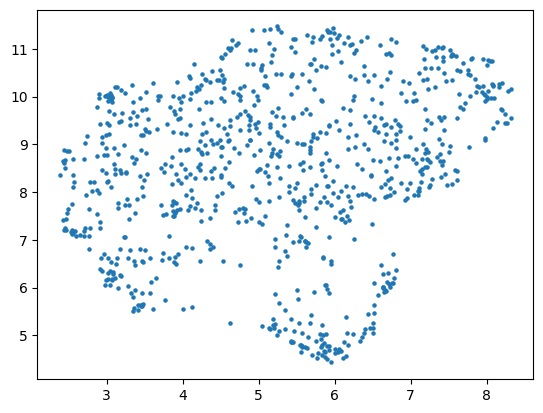

<Figure size 640x480 with 0 Axes>

In [35]:
viz_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
metric='cosine', random_state=42).fit_transform(embeddings)
plt.scatter(viz_embedding[:, 0], viz_embedding[:, 1], s=5)
plt.figure()


/opt/homebrew/anaconda3/envs/sycophancy-stakes/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Number of clusters: 20, number of noise points: 249 (27.79%)


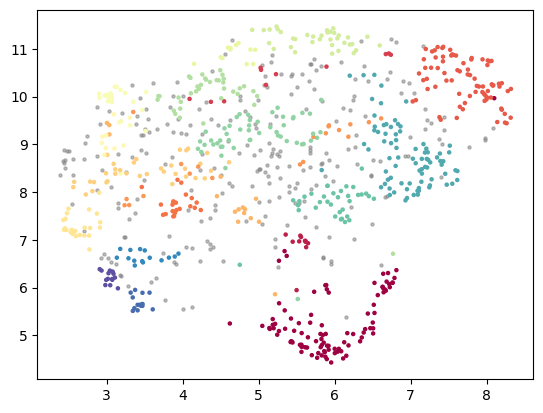

In [34]:
import hdbscan

clusterable_embedding = umap.UMAP(
    n_neighbors=10,
    min_dist=0.0,
    n_components=5,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean',
)

cluster_labels = clusterer.fit_predict(clusterable_embedding)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = np.sum(cluster_labels == -1)
print(f"Number of clusters: {n_clusters}, number of noise points: {n_noise} ({n_noise/len(cluster_labels):.2%})")

clustered = cluster_labels >= 0
plt.scatter(viz_embedding[~clustered, 0], viz_embedding[~clustered, 1],
            color=(0.5, 0.5, 0.5), s=5, alpha=0.5, label='noise')
plt.scatter(viz_embedding[clustered, 0], viz_embedding[clustered, 1],
            c=cluster_labels[clustered], s=5, cmap='Spectral')

In [ ]:
from hypothesaes.quickstart import train_sae

sae = train_sae(
    embeddings=embeddings,
    M=64, K=4,
    checkpoint_dir='./checkpoints/sycophan_filtered',
)
activations=sae.get_activations(embeddings)
print(f"Activations shape: {activations.shape}")